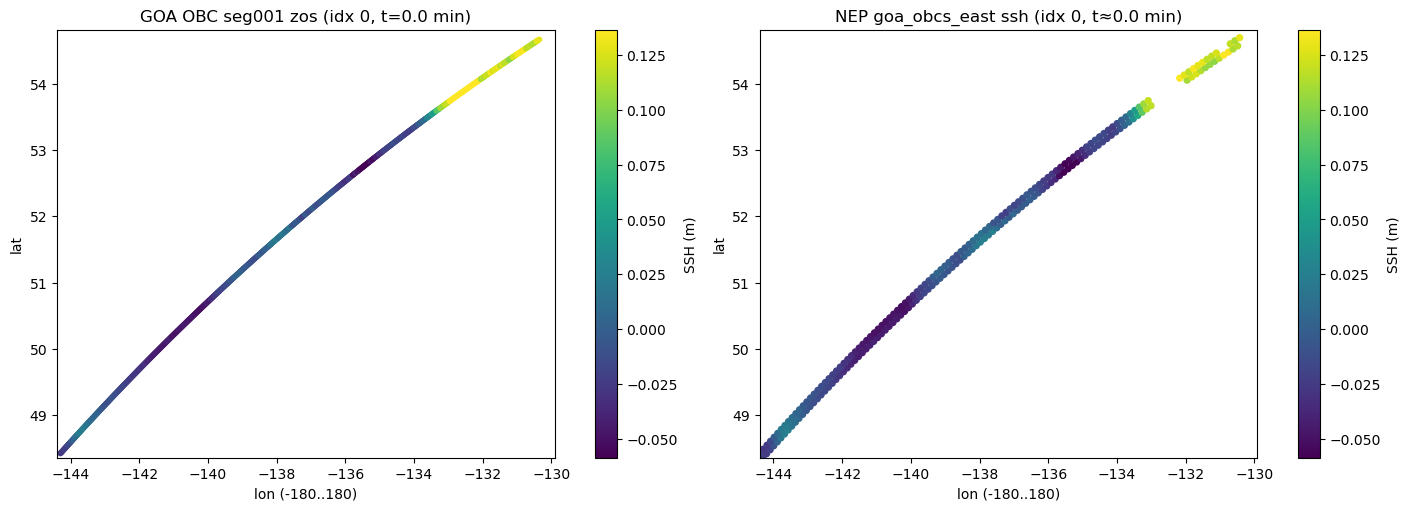

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

GOA_ZOS = "./outputs_CGOA_feb26/zos_001_1993.nc"
NEP_EAST = "/work/Remi.Pages/GOA2p5k/HINDCAST/19930101.goa_obcs_east.nc"

itime_goa = 0
target_minutes = None  # or e.g. 0.0

def _fill_to_nan(da):
    fv = da.attrs.get("_FillValue", None)
    if fv is None:
        fv = da.attrs.get("missing_value", None)
    if fv is None:
        return da
    return da.where(da != fv)

def wrap_lon_180(lon):
    """Convert lon to [-180,180) convention."""
    return ((lon + 180.0) % 360.0) - 180.0

with xr.open_dataset(GOA_ZOS, decode_times=False) as ds_goa, xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep:
    # --- GOA seg001 ---
    lon_goa = ds_goa["lon_segment_001"].values.astype(float)  # already -180..180
    lat_goa = ds_goa["lat_segment_001"].values.astype(float)
    zos_goa = _fill_to_nan(ds_goa["zos_segment_001"])

    t_goa_min = ds_goa["time"].values.astype(float)  # minutes
    if target_minutes is None:
        tmin = float(t_goa_min[itime_goa])
    else:
        tmin = float(target_minutes)
        itime_goa = int(np.argmin(np.abs(t_goa_min - tmin)))

    zos_line = zos_goa.isel(time=itime_goa, ny_segment_001=0).values.astype(float)  # (nx,)

    # --- NEP east subset ---
    ssh = _fill_to_nan(ds_nep["ssh"])
    geolon = _fill_to_nan(ds_nep["geolon"]).values.astype(float)  # (2,121) in 0..360
    geolat = _fill_to_nan(ds_nep["geolat"]).values.astype(float)

    geolon = wrap_lon_180(geolon)

    t_nep_min = 60.0 * ds_nep["time"].values.astype(float)  # hours->minutes
    itime_nep = int(np.argmin(np.abs(t_nep_min - tmin)))
    ssh_vals = ssh.isel(time=itime_nep).values.astype(float)  # (2,121)

# ---- Common color scale (robust) ----
allv = np.concatenate([zos_line[np.isfinite(zos_line)], ssh_vals.ravel()[np.isfinite(ssh_vals.ravel())]])
vmin, vmax = np.nanpercentile(allv, [2, 98])

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sc0 = axs[0].scatter(lon_goa, lat_goa, c=zos_line, s=10, vmin=vmin, vmax=vmax)
axs[0].set_title(f"GOA OBC seg001 zos (idx {itime_goa}, t={tmin:.1f} min)")
axs[0].set_xlabel("lon (-180..180)")
axs[0].set_ylabel("lat")
plt.colorbar(sc0, ax=axs[0], label="SSH (m)")

lon_flat = geolon.ravel()
lat_flat = geolat.ravel()
ssh_flat = ssh_vals.ravel()
ok = np.isfinite(lon_flat) & np.isfinite(lat_flat) & np.isfinite(ssh_flat)

sc1 = axs[1].scatter(lon_flat[ok], lat_flat[ok], c=ssh_flat[ok], s=18, vmin=vmin, vmax=vmax)
axs[1].set_title(f"NEP goa_obcs_east ssh (idx {itime_nep}, t≈{tmin:.1f} min)")
axs[1].set_xlabel("lon (-180..180)")
axs[1].set_ylabel("lat")
plt.colorbar(sc1, ax=axs[1], label="SSH (m)")

# match view window for direct visual comparison
xmin = min(np.nanmin(lon_goa), np.nanmin(lon_flat[ok]))
xmax = max(np.nanmax(lon_goa), np.nanmax(lon_flat[ok]))
ymin = min(np.nanmin(lat_goa), np.nanmin(lat_flat[ok]))
ymax = max(np.nanmax(lat_goa), np.nanmax(lat_flat[ok]))
for ax in axs:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

plt.show()


=== NEP ssh vs GOA zos (nearest point match) ===
           N: 220
        corr: 0.9931431925981687
   bias_mean: -5.476494273104684e-05
 bias_median: 0.0
        rmse: 0.005988870328375606
         mae: 0.003350971256424435
       medae: 0.0
       std_x: 0.05097907674436552
       std_y: 0.05121766035915135
 p10_abs_err: 0.0
 p50_abs_err: 0.0
 p90_abs_err: 0.009044826756507973
 dist_km_med: 5.075848787100573
 dist_km_p90: 5.077779668650514
 dist_km_max: 7.176713507383193
 unique_GOAp: 112 / 961
    max_dups: 2


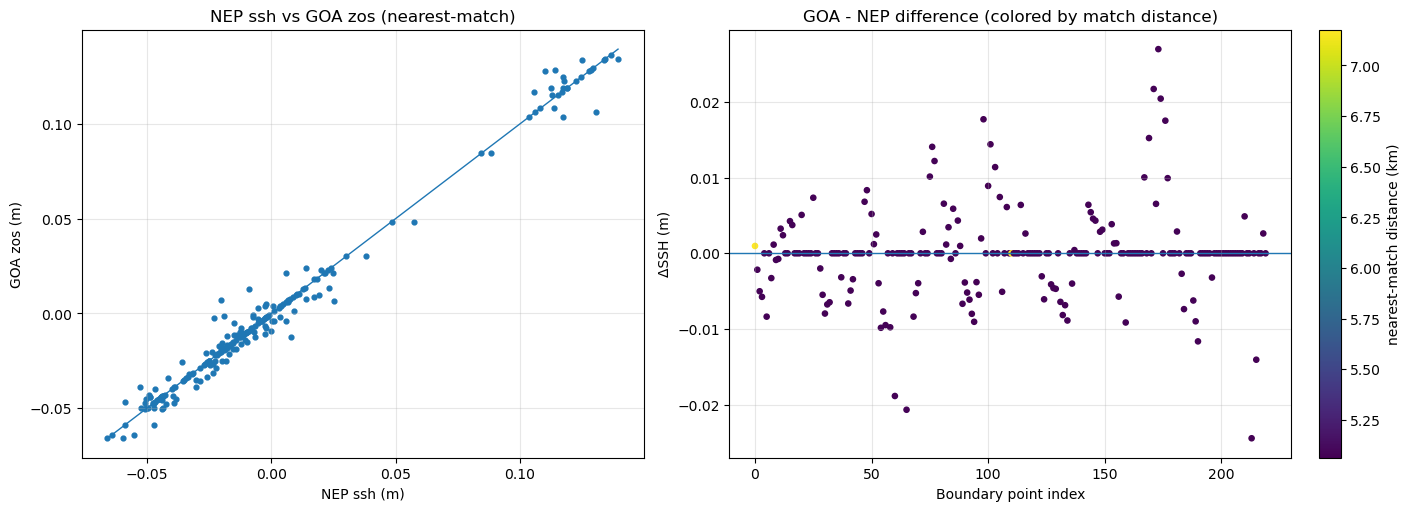

In [2]:
#!/usr/bin/env python3
"""
Quantitative verification: NEP ssh vs GOA OBC seg001 zos at matching lon/lat points.

Method:
- Wrap NEP lon (0..360) to (-180..180) so lon conventions match.
- For each NEP boundary point (geolon/geolat, 2x121), find nearest GOA seg001 point
  (lon_segment_001/lat_segment_001, 961).
- Compare ssh (NEP) vs zos (GOA) at a chosen time (matched by elapsed minutes).

No field interpolation is done. Only nearest-point matching in coordinate space.
"""



# --- choose time ---
itime_goa = 0
target_minutes = None  # set e.g. 12345.0 if you want

def _fill_to_nan(da):
    fv = da.attrs.get("_FillValue", None)
    if fv is None:
        fv = da.attrs.get("missing_value", None)
    if fv is None:
        return da
    return da.where(da != fv)

def wrap_lon_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0

def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance (km). Inputs in degrees, supports numpy arrays."""
    R = 6371.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

def stats(x, y):
    """Return dict of common skill metrics (x=NEP, y=GOA matched)."""
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if x.size < 3:
        return {"N": int(x.size)}
    d = y - x
    out = {}
    out["N"] = int(x.size)
    out["bias_mean"] = float(np.mean(d))
    out["bias_median"] = float(np.median(d))
    out["rmse"] = float(np.sqrt(np.mean(d**2)))
    out["mae"] = float(np.mean(np.abs(d)))
    out["medae"] = float(np.median(np.abs(d)))
    out["std_x"] = float(np.std(x))
    out["std_y"] = float(np.std(y))
    out["corr"] = float(np.corrcoef(x, y)[0, 1])
    out["p10_abs_err"] = float(np.percentile(np.abs(d), 10))
    out["p50_abs_err"] = float(np.percentile(np.abs(d), 50))
    out["p90_abs_err"] = float(np.percentile(np.abs(d), 90))
    return out

# ------------------ load data ------------------
with xr.open_dataset(GOA_ZOS, decode_times=False) as ds_goa, xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep:
    # GOA segment points
    lon_goa = ds_goa["lon_segment_001"].values.astype(float)  # (nx,)
    lat_goa = ds_goa["lat_segment_001"].values.astype(float)
    zos_goa = _fill_to_nan(ds_goa["zos_segment_001"])         # (time, 1, nx)
    t_goa_min = ds_goa["time"].values.astype(float)           # minutes

    if target_minutes is None:
        tmin = float(t_goa_min[itime_goa])
    else:
        tmin = float(target_minutes)
        itime_goa = int(np.argmin(np.abs(t_goa_min - tmin)))

    zos_line = zos_goa.isel(time=itime_goa, ny_segment_001=0).values.astype(float)  # (nx,)

    # NEP boundary subset points (2 rows x 121 cols)
    ssh = _fill_to_nan(ds_nep["ssh"])                         # (time,2,121)
    lon_nep = _fill_to_nan(ds_nep["geolon"]).values.astype(float)
    lat_nep = _fill_to_nan(ds_nep["geolat"]).values.astype(float)
    lon_nep = wrap_lon_180(lon_nep)

    t_nep_min = 60.0 * ds_nep["time"].values.astype(float)    # hours -> minutes
    itime_nep = int(np.argmin(np.abs(t_nep_min - tmin)))
    ssh_2x = ssh.isel(time=itime_nep).values.astype(float)    # (2,121)

# ------------------ nearest matching ------------------
# Flatten NEP points
lonN = lon_nep.ravel()
latN = lat_nep.ravel()
sshN = ssh_2x.ravel()

okN = np.isfinite(lonN) & np.isfinite(latN) & np.isfinite(sshN)
lonN = lonN[okN]; latN = latN[okN]; sshN = sshN[okN]

# For each NEP point, find nearest GOA seg point (haversine distance)
# (Simple O(N*M): ~242*961 ~ 233k ops, totally fine)
idx_goa = np.empty(lonN.size, dtype=int)
dist_km = np.empty(lonN.size, dtype=float)

for i in range(lonN.size):
    d = haversine_km(lonN[i], latN[i], lon_goa, lat_goa)  # vector over GOA points
    j = int(np.argmin(d))
    idx_goa[i] = j
    dist_km[i] = float(d[j])

zosM = zos_line[idx_goa]  # GOA matched at nearest point

# ------------------ metrics ------------------
S = stats(sshN, zosM)
print("\n=== NEP ssh vs GOA zos (nearest point match) ===")
for k in ["N","corr","bias_mean","bias_median","rmse","mae","medae","std_x","std_y","p10_abs_err","p50_abs_err","p90_abs_err"]:
    if k in S:
        print(f"{k:>12s}: {S[k]}")
print(f"{'dist_km_med':>12s}: {float(np.median(dist_km))}")
print(f"{'dist_km_p90':>12s}: {float(np.percentile(dist_km,90))}")
print(f"{'dist_km_max':>12s}: {float(np.max(dist_km))}")

# Optional: count how many NEP points map to the same GOA point (should be small-ish)
uniq, counts = np.unique(idx_goa, return_counts=True)
print(f"{'unique_GOAp':>12s}: {uniq.size} / {lon_goa.size}")
print(f"{'max_dups':>12s}: {int(np.max(counts))}")

# ------------------ plots ------------------
# Order points along boundary for a clean 1D look:
# sort by "along-boundary distance" using NEP points as reference
# (works fine since NEP points are already arranged on 2x121 strip)
order = np.argsort(np.arange(lonN.size))  # default: keep original flatten order
# If you want a geometric ordering instead, uncomment this:
# order = np.argsort(lonN)  # crude but sometimes ok for an east boundary

x = sshN[order]
y = zosM[order]
d = (y - x)
dkm = dist_km[order]

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Scatter NEP vs GOA
axs[0].scatter(x, y, s=12)
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])
axs[0].plot([mn, mx], [mn, mx], linewidth=1)
axs[0].set_title("NEP ssh vs GOA zos (nearest-match)")
axs[0].set_xlabel("NEP ssh (m)")
axs[0].set_ylabel("GOA zos (m)")
axs[0].grid(True, alpha=0.3)

# Difference along boundary index, color by match distance
sc = axs[1].scatter(np.arange(d.size), d, c=dkm, s=14)
axs[1].axhline(0.0, linewidth=1)
axs[1].set_title("GOA - NEP difference (colored by match distance)")
axs[1].set_xlabel("Boundary point index")
axs[1].set_ylabel("ΔSSH (m)")
plt.colorbar(sc, ax=axs[1], label="nearest-match distance (km)")
axs[1].grid(True, alpha=0.3)

plt.show()

zos_line shape: (1057,)
lon_goa shape: (1057,) lat_goa shape: (1057,)
idx_goa max: 1020

=== WEST boundary NEP ssh vs GOA zos (seg002) ===
           N: 256
        corr: 0.9970597579229479
   bias_mean: -4.9256597776548006e-05
 bias_median: 0.0
        rmse: 0.005612112489683663
         mae: 0.0031698012153356103
       medae: 0.00011643208563327789
       std_x: 0.07250698048317897
       std_y: 0.0730834647252344
 p90_abs_err: 0.010974086821079254
 dist_km_med: 5.073711809559114
 dist_km_max: 7.1776948628469555


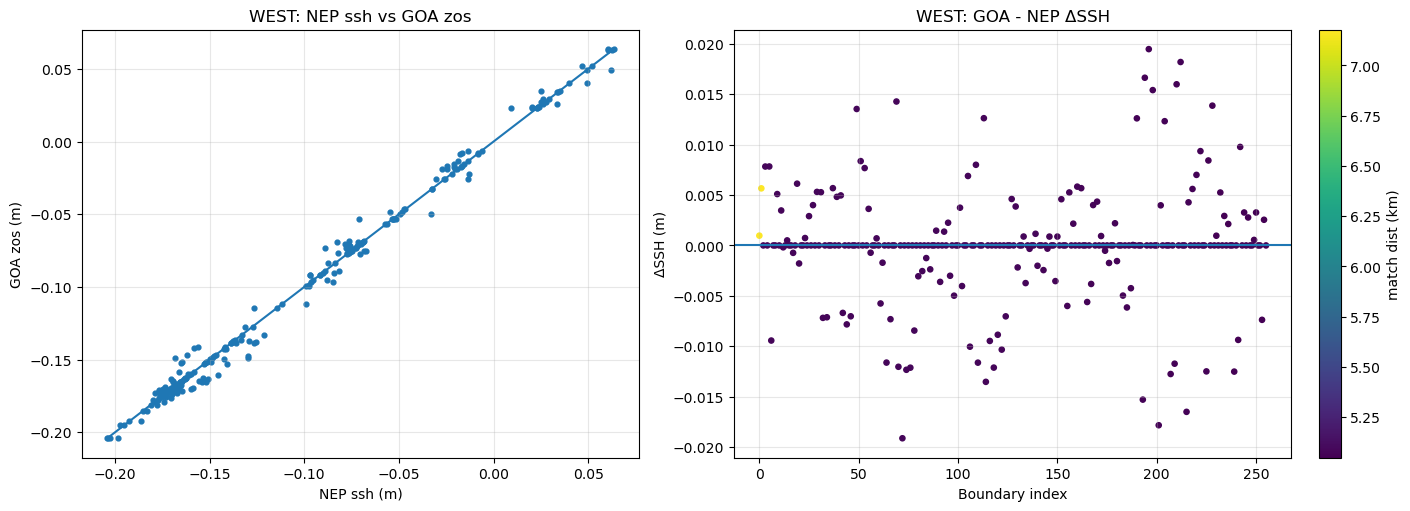

In [7]:
#!/usr/bin/env python3
"""
Quantitative verification: NEP (west) ssh vs GOA OBC seg002 zos

- No interpolation of SSH field
- Nearest-point matching in lon/lat
- Computes skill metrics
- Plots scatter + boundary difference

Assumes:
    GOA file: zos_002_1993.nc
    NEP file: 19930101.goa_obcs_west.nc
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

GOA_ZOS = "./outputs_CGOA_feb26/zos_002_1993.nc"
NEP_WEST = "/work/Remi.Pages/GOA2p5k/HINDCAST/19930101.goa_obcs_west.nc"

itime_goa = 0
target_minutes = None

# --------------------------------------------------
def _fill_to_nan(da):
    fv = da.attrs.get("_FillValue", None)
    if fv is None:
        fv = da.attrs.get("missing_value", None)
    if fv is None:
        return da
    return da.where(da != fv)

def wrap_lon_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

def stats(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    d = y - x
    return {
        "N": len(x),
        "corr": float(np.corrcoef(x, y)[0,1]),
        "bias_mean": float(np.mean(d)),
        "bias_median": float(np.median(d)),
        "rmse": float(np.sqrt(np.mean(d**2))),
        "mae": float(np.mean(np.abs(d))),
        "medae": float(np.median(np.abs(d))),
        "std_x": float(np.std(x)),
        "std_y": float(np.std(y)),
        "p90_abs_err": float(np.percentile(np.abs(d),90))
    }

# --------------------------------------------------
with xr.open_dataset(GOA_ZOS, decode_times=False) as ds_goa, \
     xr.open_dataset(NEP_WEST, decode_times=False) as ds_nep:

    # GOA seg002
    lon_goa = ds_goa["lon_segment_002"].values.astype(float)
    lat_goa = ds_goa["lat_segment_002"].values.astype(float)
    zos_goa = _fill_to_nan(ds_goa["zos_segment_002"])

    t_goa_min = ds_goa["time"].values.astype(float)

    if target_minutes is None:
        tmin = float(t_goa_min[itime_goa])
    else:
        tmin = float(target_minutes)
        itime_goa = int(np.argmin(np.abs(t_goa_min - tmin)))

    zos_line = zos_goa.isel(time=itime_goa).squeeze()
    # if still 2D, drop ny
    if zos_line.ndim == 2:
        zos_line = zos_line.isel(ny_segment_002=0)
    zos_line = zos_line.values.astype(float)
    print("zos_line shape:", zos_line.shape)
    print("lon_goa shape:", lon_goa.shape, "lat_goa shape:", lat_goa.shape)
    print("idx_goa max:", idx_goa.max())

    # NEP west file
    ssh = _fill_to_nan(ds_nep["ssh"])
    lon_nep = wrap_lon_180(_fill_to_nan(ds_nep["geolon"]).values.astype(float))
    lat_nep = _fill_to_nan(ds_nep["geolat"]).values.astype(float)

    t_nep_min = 60.0 * ds_nep["time"].values.astype(float)
    itime_nep = int(np.argmin(np.abs(t_nep_min - tmin)))

    ssh_vals = ssh.isel(time=itime_nep).values.astype(float)

# --------------------------------------------------
# Flatten NEP boundary
lonN = lon_nep.ravel()
latN = lat_nep.ravel()
sshN = ssh_vals.ravel()

ok = np.isfinite(lonN) & np.isfinite(latN) & np.isfinite(sshN)
lonN = lonN[ok]; latN = latN[ok]; sshN = sshN[ok]

# Nearest GOA point for each NEP point
idx_goa = np.empty(len(lonN), dtype=int)
dist_km = np.empty(len(lonN))

for i in range(len(lonN)):
    d = haversine_km(lonN[i], latN[i], lon_goa, lat_goa)
    j = np.argmin(d)
    idx_goa[i] = j
    dist_km[i] = d[j]

zosM = zos_line[idx_goa]

# --------------------------------------------------
S = stats(sshN, zosM)

print("\n=== WEST boundary NEP ssh vs GOA zos (seg002) ===")
for k, v in S.items():
    print(f"{k:>12s}: {v}")

print(f"{'dist_km_med':>12s}: {np.median(dist_km)}")
print(f"{'dist_km_max':>12s}: {np.max(dist_km)}")

# --------------------------------------------------
# Plots
fig, axs = plt.subplots(1,2, figsize=(14,5), constrained_layout=True)

# Scatter
axs[0].scatter(sshN, zosM, s=12)
mn = min(np.min(sshN), np.min(zosM))
mx = max(np.max(sshN), np.max(zosM))
axs[0].plot([mn,mx],[mn,mx])
axs[0].set_title("WEST: NEP ssh vs GOA zos")
axs[0].set_xlabel("NEP ssh (m)")
axs[0].set_ylabel("GOA zos (m)")
axs[0].grid(True, alpha=0.3)

# Difference
axs[1].scatter(np.arange(len(sshN)), zosM-sshN, c=dist_km, s=14)
axs[1].axhline(0)
axs[1].set_title("WEST: GOA - NEP ΔSSH")
axs[1].set_xlabel("Boundary index")
axs[1].set_ylabel("ΔSSH (m)")
plt.colorbar(axs[1].collections[0], ax=axs[1], label="match dist (km)")
axs[1].grid(True, alpha=0.3)

plt.show()

In [4]:
zos_line

array([-0.01914712])

In [5]:
idx_goa

array([   0,    0,    4,    4,   12,   12,   20,   20,   28,   28,   36,
         36,   44,   44,   52,   52,   60,   60,   68,   68,   76,   76,
         84,   84,   92,   92,  100,  100,  108,  108,  116,  116,  124,
        124,  132,  132,  140,  140,  148,  148,  156,  156,  164,  164,
        172,  172,  180,  180,  188,  188,  196,  196,  204,  204,  212,
        212,  220,  220,  228,  228,  236,  236,  244,  244,  252,  252,
        260,  260,  268,  268,  276,  276,  284,  284,  292,  292,  300,
        300,  308,  308,  316,  316,  324,  324,  332,  332,  340,  340,
        348,  348,  356,  356,  364,  364,  372,  372,  380,  380,  388,
        388,  396,  396,  404,  404,  412,  412,  420,  420,  428,  428,
        436,  436,  444,  444,  452,  452,  460,  460,  468,  468,  476,
        476,  484,  484,  492,  492,  500,  500,  508,  508,  516,  516,
        524,  524,  532,  532,  540,  540,  548,  548,  556,  556,  564,
        564,  572,  572,  580,  580,  588,  588,  5


=== seg001 U mapping ===
Nsrc: 242 median dist km: 5.075444461546311 max dist km: 5.078281889575543
=== seg001 V mapping ===
Nsrc: 121 median dist km: 0.0 max dist km: 5.074547233187394

=== U metrics (NEP uo vs GOA u_segment_001) ===
k=00  N= 223  corr=0.8889  rmse=3.1954e-02  bias=+2.4759e-03
k=05  N= 220  corr=0.9194  rmse=2.5521e-02  bias=+1.4302e-03
k=10  N= 211  corr=0.9296  rmse=2.2048e-02  bias=+1.1770e-03
k=20  N= 200  corr=0.8375  rmse=2.5369e-02  bias=+1.6767e-04
k=30  N= 192  corr=0.9023  rmse=1.3309e-02  bias=+2.1689e-04
k=40  N= 190  corr=0.9047  rmse=7.7715e-03  bias=-1.6098e-04
k=51  N=   0  corr=nan  rmse=nan  bias=+nan

=== V metrics (NEP vo vs GOA v_segment_001) ===
k=00  N= 112  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=05  N= 110  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=10  N= 107  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=20  N= 101  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=30  N=  96  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00


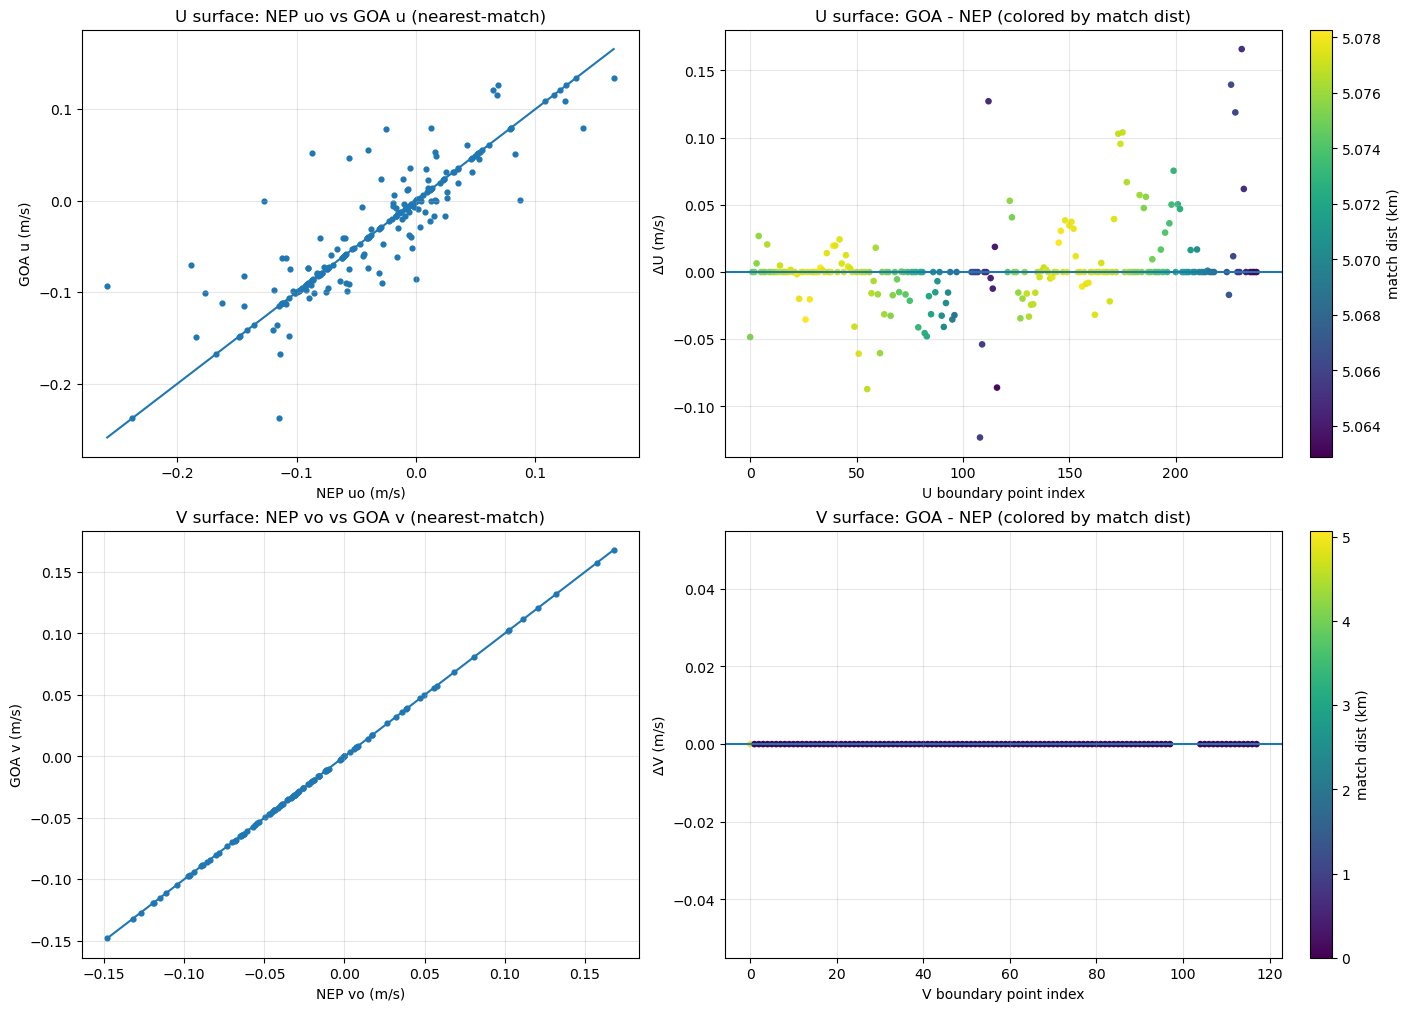


=== Depth-integrated transport (m^2/s) ===
U transport: {'N': 242, 'corr': 0.741916262773697, 'bias_mean': 13.303929807469153, 'rmse': 68.36085368854546, 'mae': 40.509953177598305, 'p90_abs_err': 105.98082620442439}
V transport: {'N': 121, 'corr': 0.9145424768185173, 'bias_mean': 6.857067214942163, 'rmse': 63.01491878669159, 'mae': 32.88448413039847, 'p90_abs_err': 90.61749170068651}


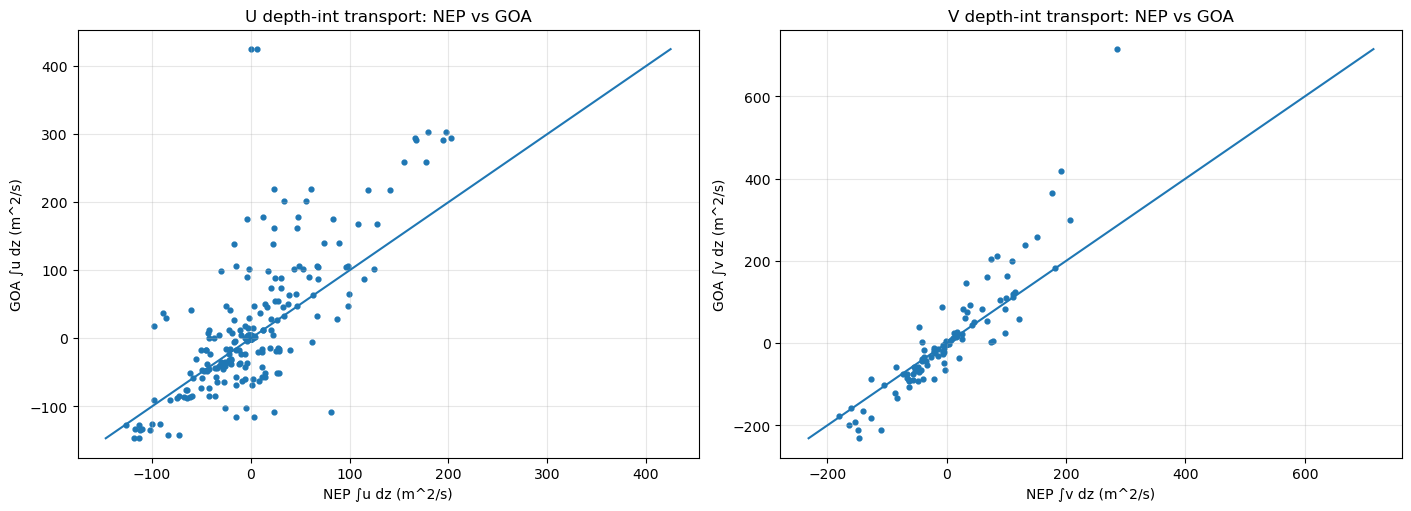

In [9]:
#!/usr/bin/env python3
"""
Quantitative verification: NEP east uo/vo vs GOA OBC seg001 u/v

- No interpolation of NEP fields onto GOA.
- Nearest-point matching in lon/lat space.
- Handles different NEP staggered grids:
    uo uses geolon_u/geolat_u (jh_sub04, iq_sub02)
    vo uses geolon_v/geolat_v (jq_sub02, ih_sub04)
- GOA seg001 uses lon_segment_001/lat_segment_001 (nx=961)

Outputs:
- Metrics for U and V at surface and a few depth indices
- Optional: depth-integrated transport check using dz_u_segment_001 and dz_v_segment_001
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

GOA_UV = "./outputs_CGOA_feb26/uv_001_1993.nc"
NEP_EAST = "/work/Remi.Pages/GOA2p5k/HINDCAST/19930101.goa_obcs_east.nc"

itime_goa = 0
target_minutes = None  # set if you want specific elapsed minutes

# choose which depth indices to report (0=surface). Set to None to report all 52 (can be noisy).
report_ks = [0, 5, 10, 20, 30, 40, 51]  # adjust if you want

# Set True to do depth-integrated transport diagnostics (recommended)
DO_TRANSPORT = True

# ---------------- helpers ----------------
def _fill_to_nan(da):
    fv = da.attrs.get("_FillValue", None)
    if fv is None:
        fv = da.attrs.get("missing_value", None)
    if fv is None:
        return da
    return da.where(da != fv)

def wrap_lon_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

def metrics(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if x.size < 3:
        return {"N": int(x.size)}
    d = y - x
    return {
        "N": int(x.size),
        "corr": float(np.corrcoef(x, y)[0, 1]),
        "bias_mean": float(np.mean(d)),
        "rmse": float(np.sqrt(np.mean(d**2))),
        "mae": float(np.mean(np.abs(d))),
        "p90_abs_err": float(np.percentile(np.abs(d), 90)),
    }

def nearest_map(src_lon, src_lat, tgt_lon, tgt_lat):
    """
    Map each source point to nearest target point (lon/lat), returning indices and distances.
    src_lon/src_lat: (Ns,)
    tgt_lon/tgt_lat: (Nt,)
    """
    idx = np.empty(src_lon.size, dtype=int)
    dist = np.empty(src_lon.size, dtype=float)
    for i in range(src_lon.size):
        d = haversine_km(src_lon[i], src_lat[i], tgt_lon, tgt_lat)
        j = int(np.argmin(d))
        idx[i] = j
        dist[i] = float(d[j])
    return idx, dist

# ---------------- load data ----------------
with xr.open_dataset(GOA_UV, decode_times=False) as ds_goa, xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep:
    # GOA seg001 coords
    lon_goa = ds_goa["lon_segment_001"].values.astype(float)  # (nx,)
    lat_goa = ds_goa["lat_segment_001"].values.astype(float)

    # GOA u/v and dz
    u_goa = _fill_to_nan(ds_goa["u_segment_001"])  # (time,nz,1,nx)
    v_goa = _fill_to_nan(ds_goa["v_segment_001"])
    dz_u  = _fill_to_nan(ds_goa["dz_u_segment_001"])
    dz_v  = _fill_to_nan(ds_goa["dz_v_segment_001"])

    # time match (GOA in minutes)
    t_goa_min = ds_goa["time"].values.astype(float)
    if target_minutes is None:
        tmin = float(t_goa_min[itime_goa])
    else:
        tmin = float(target_minutes)
        itime_goa = int(np.argmin(np.abs(t_goa_min - tmin)))

    # pick NEP nearest time (NEP in hours)
    t_nep_min = 60.0 * ds_nep["time"].values.astype(float)
    itime_nep = int(np.argmin(np.abs(t_nep_min - tmin)))

    # NEP uo/vo and their coordinates
    uo = _fill_to_nan(ds_nep["uo"]).isel(time=itime_nep)  # (z, jh_sub04=2, iq_sub02=121)
    vo = _fill_to_nan(ds_nep["vo"]).isel(time=itime_nep)  # (z, jq_sub02=1, ih_sub04=121)

    lon_u = wrap_lon_180(_fill_to_nan(ds_nep["geolon_u"]).values.astype(float))  # (2,121)
    lat_u = _fill_to_nan(ds_nep["geolat_u"]).values.astype(float)
    lon_v = wrap_lon_180(_fill_to_nan(ds_nep["geolon_v"]).values.astype(float))  # (1,121)
    lat_v = _fill_to_nan(ds_nep["geolat_v"]).values.astype(float)

# ---------------- flatten NEP points ----------------
# U points
lonU = lon_u.ravel()
latU = lat_u.ravel()
# V points
lonV = lon_v.ravel()
latV = lat_v.ravel()

# Precompute mapping from NEP U points -> GOA seg points, and NEP V points -> GOA seg points
okU = np.isfinite(lonU) & np.isfinite(latU)
okV = np.isfinite(lonV) & np.isfinite(latV)

idxU, distU = nearest_map(lonU[okU], latU[okU], lon_goa, lat_goa)
idxV, distV = nearest_map(lonV[okV], latV[okV], lon_goa, lat_goa)

print("\n=== seg001 U mapping ===")
print("Nsrc:", okU.sum(), "median dist km:", float(np.median(distU)), "max dist km:", float(np.max(distU)))
print("=== seg001 V mapping ===")
print("Nsrc:", okV.sum(), "median dist km:", float(np.median(distV)), "max dist km:", float(np.max(distV)))

# ---------------- comparisons by depth ----------------
# Extract GOA at matched time
uG = u_goa.isel(time=itime_goa, ny_segment_001=0).values.astype(float)  # (nz,nx)
vG = v_goa.isel(time=itime_goa, ny_segment_001=0).values.astype(float)  # (nz,nx)

# NEP arrays (z, 2,121) and (z,1,121)
uN_all = uo.values.astype(float).reshape(uo.shape[0], -1)  # (nz, 242)
vN_all = vo.values.astype(float).reshape(vo.shape[0], -1)  # (nz, 121)

# Apply coord masks to match flattened points
uN_all = uN_all[:, okU]  # (nz, NptsU)
vN_all = vN_all[:, okV]  # (nz, NptsV)

# Matched GOA samples
uM_all = uG[:, idxU]      # (nz, NptsU)
vM_all = vG[:, idxV]      # (nz, NptsV)

# Which depth indices to report
nz = uG.shape[0]
if report_ks is None:
    ks = list(range(nz))
else:
    ks = [k for k in report_ks if 0 <= k < nz]

print("\n=== U metrics (NEP uo vs GOA u_segment_001) ===")
for k in ks:
    S = metrics(uN_all[k, :], uM_all[k, :])
    print(f"k={k:02d}  N={S.get('N',0):4d}  corr={S.get('corr',np.nan):.4f}  rmse={S.get('rmse',np.nan):.4e}  bias={S.get('bias_mean',np.nan):+.4e}")

print("\n=== V metrics (NEP vo vs GOA v_segment_001) ===")
for k in ks:
    S = metrics(vN_all[k, :], vM_all[k, :])
    print(f"k={k:02d}  N={S.get('N',0):4d}  corr={S.get('corr',np.nan):.4f}  rmse={S.get('rmse',np.nan):.4e}  bias={S.get('bias_mean',np.nan):+.4e}")

# ---------------- plots for surface (k=0) ----------------
k0 = 0

fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# U scatter
axs[0,0].scatter(uN_all[k0,:], uM_all[k0,:], s=12)
mn = min(np.nanmin(uN_all[k0,:]), np.nanmin(uM_all[k0,:]))
mx = max(np.nanmax(uN_all[k0,:]), np.nanmax(uM_all[k0,:]))
axs[0,0].plot([mn,mx],[mn,mx])
axs[0,0].set_title("U surface: NEP uo vs GOA u (nearest-match)")
axs[0,0].set_xlabel("NEP uo (m/s)")
axs[0,0].set_ylabel("GOA u (m/s)")
axs[0,0].grid(True, alpha=0.3)

# U difference along boundary
axs[0,1].scatter(np.arange(uN_all.shape[1]), uM_all[k0,:]-uN_all[k0,:], c=distU, s=14)
axs[0,1].axhline(0)
axs[0,1].set_title("U surface: GOA - NEP (colored by match dist)")
axs[0,1].set_xlabel("U boundary point index")
axs[0,1].set_ylabel("ΔU (m/s)")
plt.colorbar(axs[0,1].collections[0], ax=axs[0,1], label="match dist (km)")
axs[0,1].grid(True, alpha=0.3)

# V scatter
axs[1,0].scatter(vN_all[k0,:], vM_all[k0,:], s=12)
mn = min(np.nanmin(vN_all[k0,:]), np.nanmin(vM_all[k0,:]))
mx = max(np.nanmax(vN_all[k0,:]), np.nanmax(vM_all[k0,:]))
axs[1,0].plot([mn,mx],[mn,mx])
axs[1,0].set_title("V surface: NEP vo vs GOA v (nearest-match)")
axs[1,0].set_xlabel("NEP vo (m/s)")
axs[1,0].set_ylabel("GOA v (m/s)")
axs[1,0].grid(True, alpha=0.3)

# V difference along boundary
axs[1,1].scatter(np.arange(vN_all.shape[1]), vM_all[k0,:]-vN_all[k0,:], c=distV, s=14)
axs[1,1].axhline(0)
axs[1,1].set_title("V surface: GOA - NEP (colored by match dist)")
axs[1,1].set_xlabel("V boundary point index")
axs[1,1].set_ylabel("ΔV (m/s)")
plt.colorbar(axs[1,1].collections[0], ax=axs[1,1], label="match dist (km)")
axs[1,1].grid(True, alpha=0.3)

plt.show()

# ---------------- transport check ----------------
if DO_TRANSPORT:
    # GOA: depth-integrated transport per matched point (m^2/s) using dz
    dzU = dz_u.isel(time=itime_goa, ny_segment_001=0).values.astype(float)  # (nz,nx)
    dzV = dz_v.isel(time=itime_goa, ny_segment_001=0).values.astype(float)

    TU_goa = np.nansum(uG * dzU, axis=0)  # (nx,)
    TV_goa = np.nansum(vG * dzV, axis=0)

    # NEP: approximate depth-integrated with its own z thickness if available:
    # If NEP has layer thickness, use it. If not, skip and just compare profiles.
    # We'll try to infer dz from z_i if present.
    try:
        # reopen for z_i (small overhead is fine)
        with xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep2:
            z_i = ds_nep2["z_i"].values.astype(float)  # (nz+1)
        dz_nep = np.diff(z_i)  # (nz,)
        TU_nep = np.nansum(uN_all * dz_nep[:, None], axis=0)  # (NptsU,)
        TV_nep = np.nansum(vN_all * dz_nep[:, None], axis=0)  # (NptsV,)

        TU_match = TU_goa[idxU]
        TV_match = TV_goa[idxV]
        # require positive thickness in GOA
        okU = np.nansum(dzU[:, idxU], axis=0) > 0
        okV = np.nansum(dzV[:, idxV], axis=0) > 0
        TU_nep2, TU_match2 = TU_nep[okU], TU_match[okU]
        TV_nep2, TV_match2 = TV_nep[okV], TV_match[okV]

        SuT = metrics(TU_nep, TU_match)
        SvT = metrics(TV_nep, TV_match)

        print("\n=== Depth-integrated transport (m^2/s) ===")
        print("U transport:", SuT)
        print("V transport:", SvT)

        fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
        axs[0].scatter(TU_nep, TU_match, s=12)
        mn = min(np.nanmin(TU_nep), np.nanmin(TU_match))
        mx = max(np.nanmax(TU_nep), np.nanmax(TU_match))
        axs[0].plot([mn,mx],[mn,mx])
        axs[0].set_title("U depth-int transport: NEP vs GOA")
        axs[0].set_xlabel("NEP ∫u dz (m^2/s)")
        axs[0].set_ylabel("GOA ∫u dz (m^2/s)")
        axs[0].grid(True, alpha=0.3)

        axs[1].scatter(TV_nep2, TV_match, s=12)
        mn = min(np.nanmin(TV_nep2), np.nanmin(TV_match))
        mx = max(np.nanmax(TV_nep2), np.nanmax(TV_match))
        axs[1].plot([mn,mx],[mn,mx])
        axs[1].set_title("V depth-int transport: NEP vs GOA")
        axs[1].set_xlabel("NEP ∫v dz (m^2/s)")
        axs[1].set_ylabel("GOA ∫v dz (m^2/s)")
        axs[1].grid(True, alpha=0.3)

        plt.show()

    except Exception as e:
        print("\n[Transport check skipped] Could not build NEP dz from z_i:", repr(e))

In [8]:
# Compare vertical thickness definitions
print("NEP dz stats (m):", np.nanmin(dz_nep), np.nanmax(dz_nep), np.nanmean(dz_nep))

print("GOA dz_u stats (m):", np.nanmin(dzU), np.nanmax(dzU), np.nanmean(dzU))
print("GOA dz_v stats (m):", np.nanmin(dzV), np.nanmax(dzV), np.nanmean(dzV))

# How different are GOA dz profiles from NEP dz?
# (use a representative boundary point)
j = idxU[len(idxU)//2]
print("dzU at one point vs NEP dz (first 10):")
print(dzU[:10, j], dz_nep[:10])

# Mask transport to where dz is valid
maskU = np.isfinite(TU_nep) & np.isfinite(TU_match)
maskV = np.isfinite(TV_nep) & np.isfinite(TV_match)
print("Transport valid counts:", maskU.sum(), maskV.sum())

NEP dz stats (m): 5.0 500.0 125.0
GOA dz_u stats (m): 5.0 500.0 125.0
GOA dz_v stats (m): 5.0 500.0 125.0
dzU at one point vs NEP dz (first 10):
[5.   5.   5.   5.   5.   5.   5.   5.   5.   6.25] [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
Transport valid counts: 242 121


weights U: n= 961 S unique: [1.]
weights V: n= 961 S unique: [1.]
row_u min/max: 0 960 expected 0.. 241
col_u min/max: 0 241 expected 0.. 960

=== Exact mapping check using weights (seg001) ===

U (NEP donor -> GOA target):
k=00  N= 883  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=05  N= 875  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=10  N= 846  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=20  N= 803  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=30  N= 765  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=40  N= 756  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00

V (NEP donor -> GOA target):
k=00  N= 888  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=05  N= 872  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=10  N= 848  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=20  N= 800  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=30  N= 760  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00
k=40  N= 753  corr=1.0000  rmse=0.0000e+00  bias=+0.0000e+00


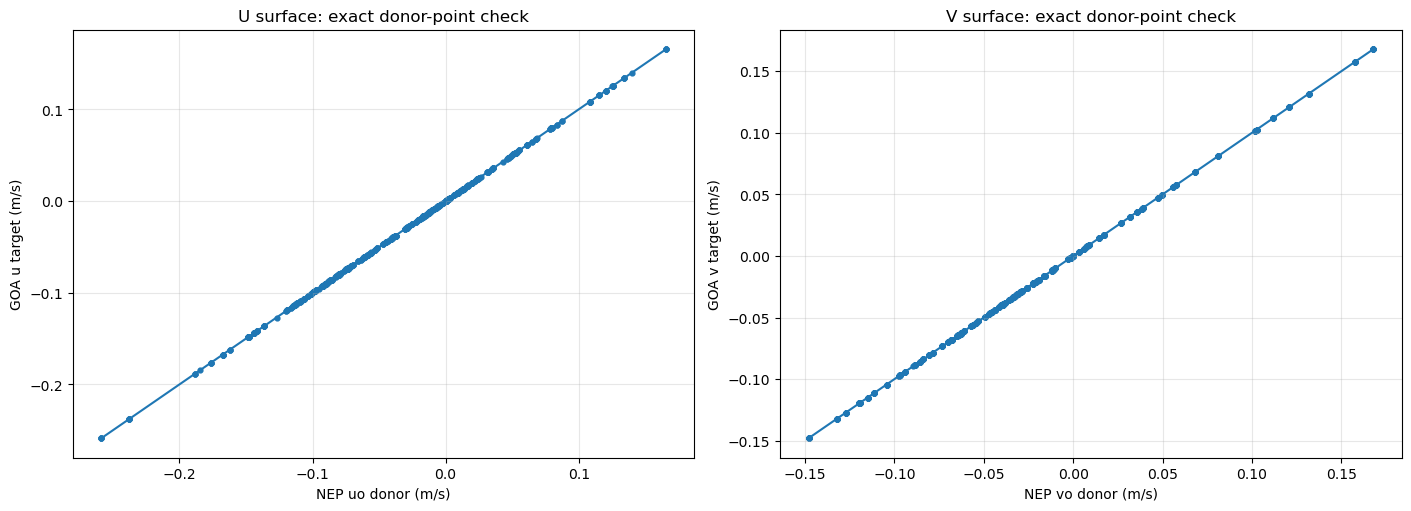


=== Depth-integrated transport (m^2/s) ===
U transport: {'N': 961, 'corr': 0.8143304712143798, 'bias_mean': 13.277010216261223, 'rmse': 63.61681611915985, 'mae': 34.33575056641085, 'p90_abs_err': 91.86115601100028}
V transport: {'N': 961, 'corr': 0.9169668992590627, 'bias_mean': 6.783882934634017, 'rmse': 63.883331187973006, 'mae': 32.78264419521866, 'p90_abs_err': 90.61749170068651}


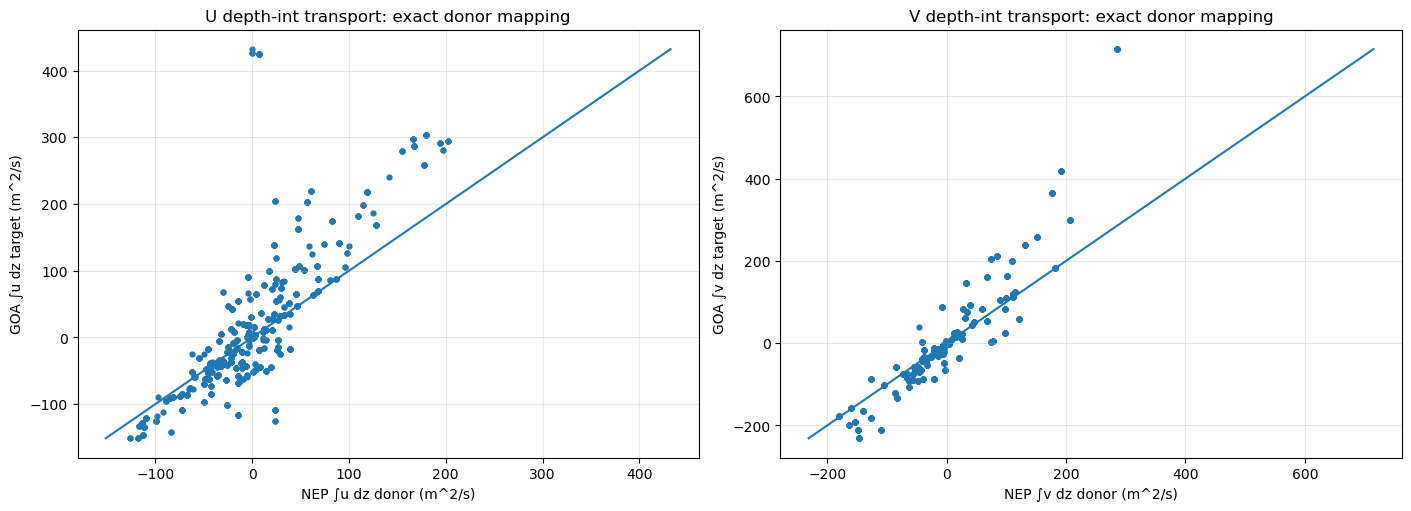

In [14]:
#!/usr/bin/env python3
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

GOA_UV   = "./outputs_CGOA_feb26/uv_001_1993.nc"
NEP_EAST = "/work/Remi.Pages/GOA2p5k/HINDCAST/19930101.goa_obcs_east.nc"

W_U = "./outputs_CGOA_feb26/regrid_segment_001_u.nc"
W_V = "./outputs_CGOA_feb26/regrid_segment_001_v.nc"

itime_goa = 0
target_minutes = None

report_ks = [0, 5, 10, 20, 30, 40]   # pick what you like
DO_TRANSPORT = True

def _fill_to_nan(da):
    fv = da.attrs.get("_FillValue", None)
    if fv is None:
        fv = da.attrs.get("missing_value", None)
    if fv is None:
        return da
    return da.where(da != fv)

def metrics(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if x.size < 3:
        return {"N": int(x.size)}
    d = y - x
    return {
        "N": int(x.size),
        "corr": float(np.corrcoef(x, y)[0, 1]),
        "bias_mean": float(np.mean(d)),
        "rmse": float(np.sqrt(np.mean(d**2))),
        "mae": float(np.mean(np.abs(d))),
        "p90_abs_err": float(np.percentile(np.abs(d), 90)),
    }

# ---------- load weights ----------
wu = xr.open_dataset(W_U)
wv = xr.open_dataset(W_V)

# xESMF uses 0-based indexing for row/col in these files (typically)
row_u = wu["row"].values.astype(int)
col_u = wu["col"].values.astype(int)
Su    = wu["S"].values

row_v = wv["row"].values.astype(int)
col_v = wv["col"].values.astype(int)
Sv    = wv["S"].values

print("weights U: n=", row_u.size, "S unique:", np.unique(Su[~np.isnan(Su)])[:5])
print("weights V: n=", row_v.size, "S unique:", np.unique(Sv[~np.isnan(Sv)])[:5])

# ---------- load datasets ----------
with xr.open_dataset(GOA_UV, decode_times=False) as ds_goa, xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep:
    # time match
    t_goa_min = ds_goa["time"].values.astype(float)  # minutes
    if target_minutes is None:
        tmin = float(t_goa_min[itime_goa])
    else:
        tmin = float(target_minutes)
        itime_goa = int(np.argmin(np.abs(t_goa_min - tmin)))

    t_nep_min = 60.0 * ds_nep["time"].values.astype(float)  # hours -> minutes
    itime_nep = int(np.argmin(np.abs(t_nep_min - tmin)))

    # GOA u/v and dz (target)
    u_goa = _fill_to_nan(ds_goa["u_segment_001"]).isel(time=itime_goa, ny_segment_001=0).values  # (nz,nx)
    v_goa = _fill_to_nan(ds_goa["v_segment_001"]).isel(time=itime_goa, ny_segment_001=0).values
    dz_u  = _fill_to_nan(ds_goa["dz_u_segment_001"]).isel(time=itime_goa, ny_segment_001=0).values
    dz_v  = _fill_to_nan(ds_goa["dz_v_segment_001"]).isel(time=itime_goa, ny_segment_001=0).values

    # NEP uo/vo (source)
    uo = _fill_to_nan(ds_nep["uo"]).isel(time=itime_nep).values  # (nz,2,121)
    vo = _fill_to_nan(ds_nep["vo"]).isel(time=itime_nep).values  # (nz,1,121)

    nz = uo.shape[0]

# Flatten NEP source grids in the same way xESMF did:
# uo source shape: (2,121) -> 242
# vo source shape: (1,121) -> 121
uo_flat = uo.reshape(nz, -1)  # (nz,242)
vo_flat = vo.reshape(nz, -1)  # (nz,121)

# GOA target is (nx=961) along segment
# We'll compare only the col indices present in the mapping
# and assume GOA arrays are indexed 0..nx-1
# (If indices look 1-based, we’ll detect and fix below)

def _maybe_fix_one_based(row, nsrc, name):
    # if max == nsrc, likely 1-based
    if row.max() == nsrc:
        print(f"[{name}] row looks 1-based; subtracting 1")
        return row - 1
    return row

def _maybe_fix_one_based_col(col, ntgt, name):
    if col.max() == ntgt:
        print(f"[{name}] col looks 1-based; subtracting 1")
        return col - 1
    return col

row_u = _maybe_fix_one_based(row_u, uo_flat.shape[1], "U")
col_u = _maybe_fix_one_based_col(col_u, u_goa.shape[1], "U")
row_v = _maybe_fix_one_based(row_v, vo_flat.shape[1], "V")
col_v = _maybe_fix_one_based_col(col_v, v_goa.shape[1], "V")

# ---- fix 1-based indexing in weights (common in some saved mappings) ----
row_u = row_u - 1
row_v = row_v - 1
col_u = col_u - 1
col_v = col_v - 1
print("row_u min/max:", row_u.min(), row_u.max(), "expected 0..", uo_flat.shape[1]-1)
print("col_u min/max:", col_u.min(), col_u.max(), "expected 0..", u_goa.shape[1]-1)
# ---------- donor-point comparison ----------
ks = [k for k in report_ks if 0 <= k < nz]

print("\n=== Exact mapping check using weights (seg001) ===")

print("\nU (NEP donor -> GOA target):")
for k in ks:
    src_u = col_u
    tgt_u = row_u
    nep = uo_flat[k, src_u]
    goa = u_goa[k, tgt_u]
    S = metrics(nep, goa)
    print(f"k={k:02d}  N={S.get('N',0):4d}  corr={S.get('corr',np.nan):.4f}  rmse={S.get('rmse',np.nan):.4e}  bias={S.get('bias_mean',np.nan):+.4e}")

print("\nV (NEP donor -> GOA target):")
for k in ks:
    src_v = col_v
    tgt_v = row_v
    nep = vo_flat[k, src_v]
    goa = v_goa[k, tgt_v]
    S = metrics(nep, goa)
    print(f"k={k:02d}  N={S.get('N',0):4d}  corr={S.get('corr',np.nan):.4f}  rmse={S.get('rmse',np.nan):.4e}  bias={S.get('bias_mean',np.nan):+.4e}")

# ---------- quick plots at surface ----------
k0 = 0
src_u = col_u; tgt_u = row_u
src_v = col_v; tgt_v = row_v

u_nep0 = uo_flat[k0, src_u]; u_goa0 = u_goa[k0, tgt_u]
v_nep0 = vo_flat[k0, src_v]; v_goa0 = v_goa[k0, tgt_v]

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axs[0].scatter(u_nep0, u_goa0, s=12)
mn = min(np.nanmin(u_nep0), np.nanmin(u_goa0))
mx = max(np.nanmax(u_nep0), np.nanmax(u_goa0))
axs[0].plot([mn,mx],[mn,mx])
axs[0].set_title("U surface: exact donor-point check")
axs[0].set_xlabel("NEP uo donor (m/s)")
axs[0].set_ylabel("GOA u target (m/s)")
axs[0].grid(True, alpha=0.3)

axs[1].scatter(v_nep0, v_goa0, s=12)
mn = min(np.nanmin(v_nep0), np.nanmin(v_goa0))
mx = max(np.nanmax(v_nep0), np.nanmax(v_goa0))
axs[1].plot([mn,mx],[mn,mx])
axs[1].set_title("V surface: exact donor-point check")
axs[1].set_xlabel("NEP vo donor (m/s)")
axs[1].set_ylabel("GOA v target (m/s)")
axs[1].grid(True, alpha=0.3)

plt.show()

# ---------- optional: depth-integrated transport with the SAME donor mapping ----------
if DO_TRANSPORT:
    # Use NEP dz from z_i (same as before)
    with xr.open_dataset(NEP_EAST, decode_times=False) as ds_nep2:
        dz_nep = np.diff(ds_nep2["z_i"].values.astype(float))  # (nz,)

    # depth thickness
    dz_nep = np.diff(ds_nep2["z_i"].values.astype(float))  # (nz,)
    dz_nep = dz_nep[:, None]  # (nz,1)
    
    # ---- U ----
    TU_nep = np.nansum(uo_flat[:, col_u] * dz_nep, axis=0)
    TU_goa = np.nansum(u_goa[:, row_u] * dzU[:, row_u], axis=0)
    
    # ---- V ----
    TV_nep = np.nansum(vo_flat[:, col_v] * dz_nep, axis=0)
    TV_goa = np.nansum(v_goa[:, row_v] * dzV[:, row_v], axis=0)
    
    SuT = metrics(TU_nep, TU_goa)
    SvT = metrics(TV_nep, TV_goa)
    
    print("\n=== Depth-integrated transport (m^2/s) ===")
    print("U transport:", SuT)
    print("V transport:", SvT)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    axs[0].scatter(TU_nep, TU_goa, s=12)
    mn = min(np.nanmin(TU_nep), np.nanmin(TU_goa))
    mx = max(np.nanmax(TU_nep), np.nanmax(TU_goa))
    axs[0].plot([mn,mx],[mn,mx])
    axs[0].set_title("U depth-int transport: exact donor mapping")
    axs[0].set_xlabel("NEP ∫u dz donor (m^2/s)")
    axs[0].set_ylabel("GOA ∫u dz target (m^2/s)")
    axs[0].grid(True, alpha=0.3)

    axs[1].scatter(TV_nep, TV_goa, s=12)
    mn = min(np.nanmin(TV_nep), np.nanmin(TV_goa))
    mx = max(np.nanmax(TV_nep), np.nanmax(TV_goa))
    axs[1].plot([mn,mx],[mn,mx])
    axs[1].set_title("V depth-int transport: exact donor mapping")
    axs[1].set_xlabel("NEP ∫v dz donor (m^2/s)")
    axs[1].set_ylabel("GOA ∫v dz target (m^2/s)")
    axs[1].grid(True, alpha=0.3)

    plt.show()

In [15]:
H_nep_u = np.nansum(dz_nep) * np.ones_like(col_u, dtype=float)   # same everywhere in your code
H_goa_u = np.nansum(dzU[:, row_u], axis=0)

print("H_goa_u min/med/max:", np.nanmin(H_goa_u), np.nanmedian(H_goa_u), np.nanmax(H_goa_u))
print("H_nep_u (const):", np.nansum(dz_nep))
print("fraction where H_goa_u differs by >5%:", np.mean(np.abs(H_goa_u - np.nansum(dz_nep)) / np.nansum(dz_nep) > 0.05))

H_goa_u min/med/max: 6500.0 6500.0 6500.0
H_nep_u (const): 6500.0
fraction where H_goa_u differs by >5%: 0.0


In [16]:
# indices (consistent with your working donor-point check)
tgt_u = row_u   # GOA target: 0..960
src_u = col_u   # NEP donor : 0..241

tgt_v = row_v
src_v = col_v

# dz_nep: (nz,)
dz_nep = np.diff(ds_nep2["z_i"].values.astype(float))  # (nz,)
dz_nep2d = dz_nep[:, None]  # (nz,1)

# Depth-integrated (m^2/s)
TU_nep = np.nansum(uo_flat[:, src_u] * dz_nep2d, axis=0)             # (961,)
TU_goa = np.nansum(u_goa[:, tgt_u] * dzU[:, tgt_u], axis=0)          # (961,)

TV_nep = np.nansum(vo_flat[:, src_v] * dz_nep2d, axis=0)             # (961,)
TV_goa = np.nansum(v_goa[:, tgt_v] * dzV[:, tgt_v], axis=0)          # (961,)

print("max|TU_goa - TU_nep|:", np.nanmax(np.abs(TU_goa - TU_nep)))
print("max|TV_goa - TV_nep|:", np.nanmax(np.abs(TV_goa - TV_nep)))

max|TU_goa - TU_nep|: 432.8585875709541
max|TV_goa - TV_nep|: 428.79363287240267


In [17]:
# Use GOA dz for BOTH integrals (this tests consistency of u with GOA dz)
TU_nep_goaDz = np.nansum(uo_flat[:, src_u] * dzU[:, tgt_u], axis=0)
TU_goa       = np.nansum(u_goa[:, tgt_u]   * dzU[:, tgt_u], axis=0)

TV_nep_goaDz = np.nansum(vo_flat[:, src_v] * dzV[:, tgt_v], axis=0)
TV_goa       = np.nansum(v_goa[:, tgt_v]   * dzV[:, tgt_v], axis=0)

print("max|TU_goa - TU_nep_goaDz|:", np.nanmax(np.abs(TU_goa - TU_nep_goaDz)))
print("max|TV_goa - TV_nep_goaDz|:", np.nanmax(np.abs(TV_goa - TV_nep_goaDz)))

max|TU_goa - TU_nep_goaDz|: 432.8469526063418
max|TV_goa - TV_nep_goaDz|: 428.65465208888054


In [18]:
import numpy as np
import xarray as xr

HGRID = "/work/Remi.Pages/GOA2p5k/GRID/CGOA_2.5k/ocean_hgrid.nc"
UV001 = "./outputs_CGOA_feb26/uv_001_1993.nc"

itime = 0  # pick time index

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

with xr.open_dataset(HGRID, decode_times=False) as hg, xr.open_dataset(UV001, decode_times=False) as obc:
    # supergrid lon/lat corners
    lon = hg["x"].values  # (nyp, nxp)
    lat = hg["y"].values

    # east boundary is at the last supergrid i index
    ie = lon.shape[1] - 1  # nxp-1 = 960

    # dy along the east boundary (distance between (j,ie) and (j+1,ie))
    dy_edge = haversine_m(lon[:-1, ie], lat[:-1, ie], lon[1:, ie], lat[1:, ie])  # length nyp-1 = 1056

    # Your seg001 length is 961 points; dy_edge is 1056 (whole domain).
    # seg001 is a subset of the full boundary. We need to map seg points to hgrid j-index.
    # The Segment class likely used the full east boundary subset based on wet points.
    # Easiest robust approach: use seg lat/lon to nearest match onto the east edge j locations.

    lon_seg = obc["lon_segment_001"].values.astype(float)  # (961,)
    lat_seg = obc["lat_segment_001"].values.astype(float)

    # build east-edge coordinate arrays at cell-centers of edge segments
    # use midpoint between corner points for matching
    lon_edge_mid = 0.5 * (lon[:-1, ie] + lon[1:, ie])
    lat_edge_mid = 0.5 * (lat[:-1, ie] + lat[1:, ie])

    # match each seg point to nearest edge-midpoint index j
    # (cheap since 961x1056 is ok)
    j_map = np.empty(lon_seg.size, dtype=int)
    for p in range(lon_seg.size):
        d = haversine_m(lon_seg[p], lat_seg[p], lon_edge_mid, lat_edge_mid)
        j_map[p] = int(np.argmin(d))

    dy_seg = dy_edge[j_map]  # (961,)

    # load u and dz on the segment (nz,nx)
    u  = obc["u_segment_001"].isel(time=itime, ny_segment_001=0).values.astype(float)   # (nz,961)
    dz = obc["dz_u_segment_001"].isel(time=itime, ny_segment_001=0).values.astype(float)

    # mask fillvalues if present
    u  = np.where(u  > 1e19, np.nan, u)
    dz = np.where(dz > 1e19, np.nan, dz)

    # compute volume flux (m3/s): sum over depth and along-boundary
    # sign convention: positive u is eastward; for east boundary, outward normal is +x,
    # so +u is outward from the domain.
    Q = np.nansum(u * dz * dy_seg[None, :])

print("seg001 east boundary net volume flux Q (m^3/s):", Q)

seg001 east boundary net volume flux Q (m^3/s): 17944365.00668006


In [19]:
Qpos = np.nansum(np.where(u>0, u, 0.0) * dz * dy_seg[None,:])
Qneg = np.nansum(np.where(u<0, u, 0.0) * dz * dy_seg[None,:])
print("Q+ (outflow) Sv:", Qpos/1e6)
print("Q- (inflow)  Sv:", Qneg/1e6)
print("Net Q Sv:", (Qpos+Qneg)/1e6)

Q+ (outflow) Sv: 61.129675088290945
Q- (inflow)  Sv: -43.18531008161087
Net Q Sv: 17.944365006680073
